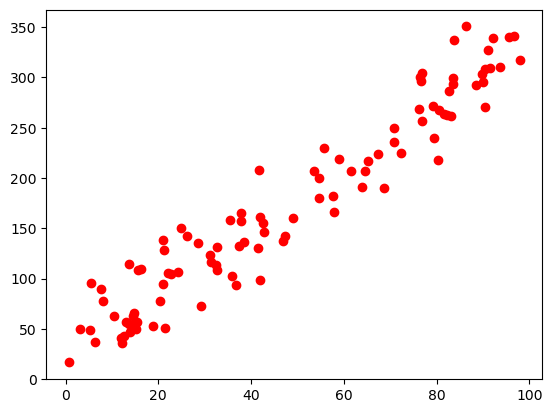

In [1]:
import matplotlib.pyplot as plt
import numpy as np

m = 100

X = np.random.uniform(0, 100, m) 

# 직선 + 약간의 랜덤 노이즈
Y = 3*X+ 30 + np.random.normal(0, 30, 100)

# 그래프
plt.scatter(X, Y, color="red")
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression

#전처리: 구조 변경 행 벡터->열 벡터
reX = X.reshape(-1,1)

# 모델 생성
model = LinearRegression()

# 학습
model.fit(reX, Y)

# 결과 확인
print("기울기 (coef):", model.coef_)
print("절편 (intercept):", model.intercept_)

기울기 (coef): [3.06011453]
절편 (intercept): 26.627541538708073


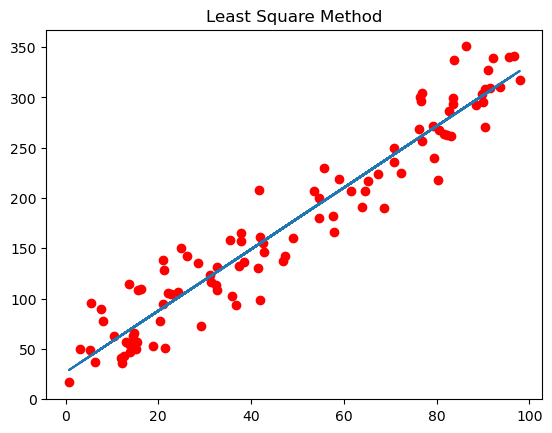

In [3]:
y_pred = model.predict(reX) # 예측

plt.title("Least Square Method")
plt.scatter(X, Y, color="red")
plt.plot(X,y_pred)
plt.show()

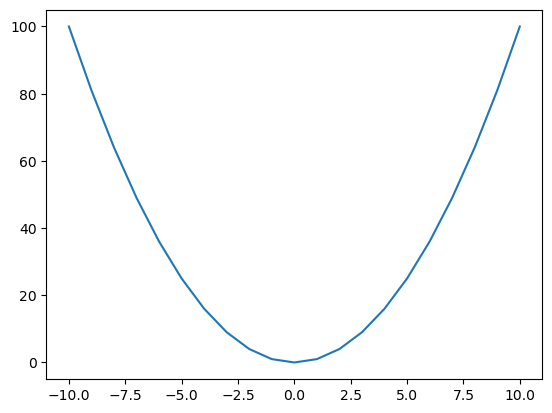

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x= np.arange(-10,11,1)
f_x = x ** 2

plt.plot(x, f_x)
plt.show()

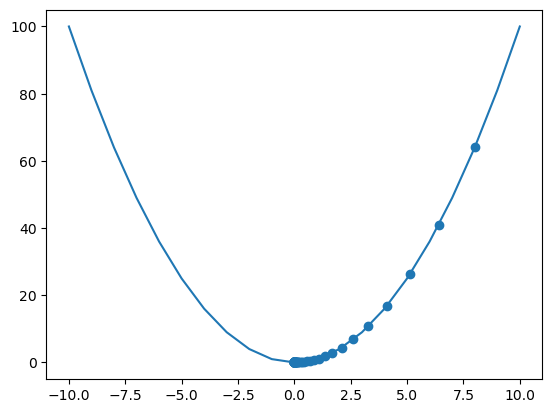

In [5]:
x_new = 10
dotX = []
y = []
learng_rate= 0.1#gradient

for i in range(100):
    old_value = x_new
    dotX.append(old_value - learng_rate * 2 * old_value)
    x_new = old_value - learng_rate *2* old_value
    y.append(x_new ** 2)
    
plt.plot(x, f_x)
plt.scatter(dotX, y)
plt.show()

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

x, y = np.arange(10).reshape((5, 2)), range(5)

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.33, random_state=42)

print(X.shape)
print(len(y))
print('-'*15)
print(X_train.shape)
print(X_test.shape)
print(len(y_train))
print(len(y_test))

(100,)
5
---------------
(3, 2)
(2, 2)
3
2


In [7]:
from sklearn.metrics import mean_squared_error

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

mean_squared_error(y_true, y_pred)

0.375

In [8]:
from sklearn.metrics import mean_absolute_error

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

mean_absolute_error(y_true, y_pred)

0.5

In [9]:
from sklearn.metrics import root_mean_squared_error

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

root_mean_squared_error(y_true, y_pred)

0.6123724356957945

In [10]:
np.sqrt(mean_squared_error(y_true, y_pred))

0.6123724356957945

In [11]:
from sklearn.metrics import r2_score

y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

r2_score(y_true, y_pred)

0.9486081370449679

In [12]:
#x 재생성
x = X.reshape(-1,1)   # (100,) -> (100,1)
bias = np.ones((m,1))# bias column
x = np.hstack((x, bias))

#theta(가중치)생성
theta = np.random.uniform(0, 1, 2)

print(x[:5])
print("초기 가중치:",theta)

[[13.61245077  1.        ]
 [70.89962288  1.        ]
 [81.6165706   1.        ]
 [93.64484002  1.        ]
 [21.08166495  1.        ]]
초기 가중치: [0.21378496 0.05491684]


In [13]:
epoch = 50
alpha = 0.0005
theta_list = []
cost_list = []

for i in range(epoch):
    hypothesis = np.dot(x, theta)     # 예측값
    loss = hypothesis - Y             # 오차
    cost = np.sum(loss ** 2) / (2 * m)# 비용함수
    gradient = np.dot(x.T, loss) / m  # ≈ 0  
    theta = theta - alpha * gradient  #가중치 업데이트

    #history 쌓기
    theta_list.append(theta)
    cost_list.append(cost)

print("최종 가중치:",theta)

최종 가중치: [3.45963049 0.28167741]


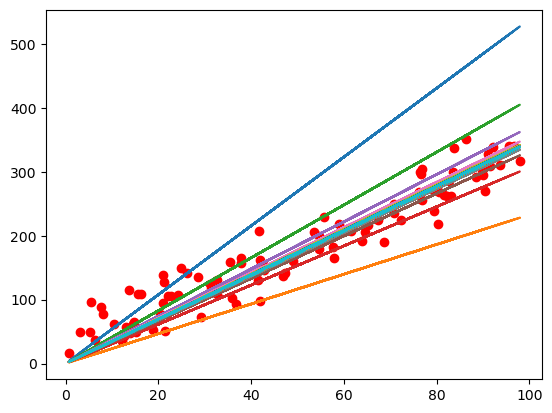

In [14]:
y_hat_step = np.dot(x, np.array(theta_list).T)

plt.plot(x[:,0],Y,"ro")#원본 데이터

for i in range (0,epoch):
    plt.plot(x[:,0],y_hat_step[:,i])

plt.show()

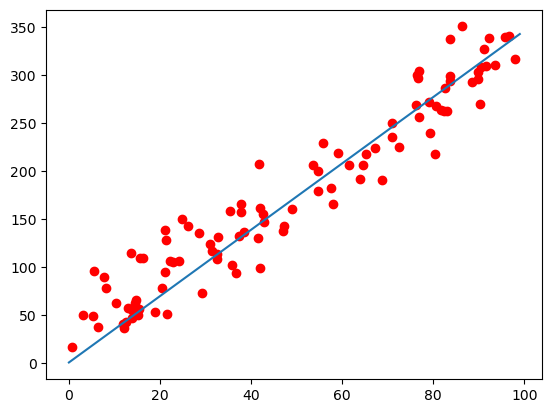

In [15]:
#원본
plt.scatter(x[:,0],Y,color="red")

#최종 모델
def model(x):
    return theta[0]*x + theta[1]
    
temp = np.arange(0,100,1)
y_hat = model(temp)

plt.plot(temp,y_hat)
plt.show()

In [16]:
data = 82 #새로운 데이터
print("data = ",data)
print("predict = ",model(data))

data =  82
predict =  283.971377973877


In [17]:
#기존 데이터로 예측값
y_predict = model(x[:,0])

mse = mean_squared_error(Y, y_predict)
mae = mean_absolute_error(Y, y_predict)
rmse = root_mean_squared_error(Y, y_predict)
r2 = r2_score(Y, y_predict)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 863.1298156567588
MAE: 22.841307488354804
RMSE: 29.37907104822681
R2: 0.9005455870911628
